# Coming from Other Analysis Tools

If you already post-process simulations — with a Python analysis package, your group's own
scripts, or the simulation code's tools — this page maps the concepts you know onto Mera and
walks one complete workflow end to end. For line-by-line language syntax (Python/MATLAB/IDL →
Julia), see the [migration cheat sheet](quickreference/02_migrators.md).

## The mental model

Mera's central design choice: **data is loaded explicitly into memory as a columnar table that
you own.** There is no lazy proxy object — after `gethydro` you hold the actual cells (one row
per AMR leaf cell), and every downstream operation is a plain function over that table. You
control RAM at load time (level cap, spatial window), not through deferred evaluation.

| Concept you may know | In Mera |
|---|---|
| snapshot / dataset object | `info = getinfo(output, path)` → metadata only, instant |
| loading data | `gethydro(info)`, `getparticles(info)`, `getgravity(info)`, … — explicit, RAM-aware |
| derived / on-the-fly fields | `getvar(gas, :T, :K)` — computed from the loaded columns; extend with `add_field` |
| geometric selection | `subregion(gas, :sphere; …)`, `shellregion(…)` — return the same table type, chainable |
| value-based selection | `filterdata(gas, …)` / `getmask` — thresholds on any `getvar` quantity |
| projections | `projection(gas, :sd, :Msol_pc2; direction=:z or any line of sight)` |
| profiles / phase diagrams | `profile(…)`, `phase(…)` |
| unit handling | a `scale` factor table: multiply, or pass the unit symbol (`:g_cm3`, `:km_s`, `:Msol_pc2`) |
| saving processed data | `savedata`/`loaddata` — compressed JLD2 (an HDF5 subset, opens in h5py too) |

Two conventions worth internalising on day one:

!!! warning "Ranges and radii in `range_unit=:standard` are box fractions"
    The default `:standard` unit means *fractions of the box* (0…1), not physical lengths.
    `xrange=[0.4, 0.6]` is the central 20% of the box; a sphere `radius=0.2` spans 20% of
    `boxlen`. Pass `range_unit=:kpc` (or `:pc`, `:Mpc`, …) with `center=[…]` to work in
    physical units — the examples below do.

- **Loading is eager, selection is cheap.** Load once (possibly windowed), then slice, filter,
  and project the in-memory table as often as you like — each step returns a normal Mera object.

## One complete workflow

The same five steps you would do anywhere: inspect → load → select → measure → map.


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, CairoMakie
CairoMakie.activate!()
BASE = MERA_EXAMPLES   # <-- change me
info = getinfo(100, joinpath(BASE, "RAMSES/spiral_clumps"));   # metadata only — instant


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0

[Mera]: 2026-08-03T12:23:46.025



Code: RAMSES


output [100] summary:
mtime: 2023-05-12T22:47:36.638
ctime: 2025-06-21T18:31:55.533
simulation time: 148.08 [Myr]
boxlen: 100.0 [kpc]
ncpu: 4
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level(s): 3 - 7 --> cellsize(s): 12.5 [kpc] - 781.25 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  

6  --> (:rho, :vx, :vy, :vz, :p, :metallicity)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :pressure, :metallicity)
γ: 1.6667
-------------------------------------------------------
gravity:       true
gravity-variables: (:epot, :ax, :ay, :az)
-------------------------------------------------------
particles:     true
- Nstars:   4.138950e+05 
- Ndm:      3.997000e+04 


particle-variables: 8  --> (:vx, :vy, :vz, :mass, :family, :tag, :birth, :metals)
particle-descriptor: (:position_x, :position_y, :position_z, :velocity_x, :velocity_y, :velocity_z, :mass, :identity, :levelp, :family, :tag, :birth_time, :metallicity)
-------------------------------------------------------
rt:            false
-------------------------------------------------------
clumps:           true
clump-variables: (

:index, :lev, :parent, :ncell, :peak_x, :peak_y, :peak_z, Symbol("rho-"), Symbol("rho+"), :rho_av, :mass_cl, :relevance)
-------------------------------------------------------
namelist-file: ("&COOLING_PARAMS", "&SF_PARAMS", "&AMR_PARAMS", "&BOUNDARY_PARAMS", "&OUTPUT_PARAMS", "&POISSON_PARAMS", "&UNITS_PARAMS", "&RUN_PARAMS", "&CLUMPFIND_PARAMS", "&FEEDBACK_PARAMS", "&HYDRO_PARAMS", "&DICE_PARAMS", "&INIT_PARAMS", "&REFINE_PARAMS")
-------------------------------------------------------
timer-file:       true
compilation-file: true
makefile:         true
patchfile:        true



`info` already knows everything about the snapshot (levels, box size, which files exist,
the unit system) without touching the heavy data. Loading is the explicit step — and the place
to bound memory with a level cap and/or a spatial window:

In [2]:
# full box here (the fixture is small); on big runs use lmax=/xrange=… to bound RAM
gas = gethydro(info, verbose=false, show_progress=false)
println(length(gas.data), " cells in memory, levels ", gas.lmin, "-", gas.lmax)
usedmemory(gas)

590311 cells in memory, levels 

3-7
Memory used: 45.486

 MB


(45.485774993896484, "MB")

Derived quantities are computed on demand from the loaded columns — with units as
symbols (every available scale is listed by `viewfields(info.scale)`):

In [3]:
T  = getvar(gas, :T, :K)               # temperature, Kelvin
cs = getvar(gas, :cs, :km_s)           # sound speed, km/s
println("T  range: ", round.(extrema(T), sigdigits=3), " K")
println("cs range: ", round.(extrema(cs), sigdigits=3), " km/s")

T  range: (

2.04, 5.82e8) K
cs range: (0.147, 2480.0) km/s


Geometric and value-based selection compose, and each result is again a full Mera
object — `getvar`, `projection`, `profile` all work on it unchanged:

In [4]:
disk = subregion(gas, :cylinder; radius=8., height=2., center=[:bc],
                 range_unit=:kpc, verbose=false)             # inner disk, physical units
cold = filterdata(disk, Below(:T, 2e4; unit=:K), verbose=false)  # value-space cut on a DERIVED quantity
println("disk: ", length(disk.data), " cells;  cold disk: ", length(cold.data), " cells")
println("cold gas mass: ", round(msum(cold, :Msol), sigdigits=4), " Msol")

disk: 2256

 cells;  cold disk: 1181 cells
cold gas mass: 2.209e9

 Msol


Maps and profiles close the loop — a face-on surface-density map of the cold disk and
its radial profile:

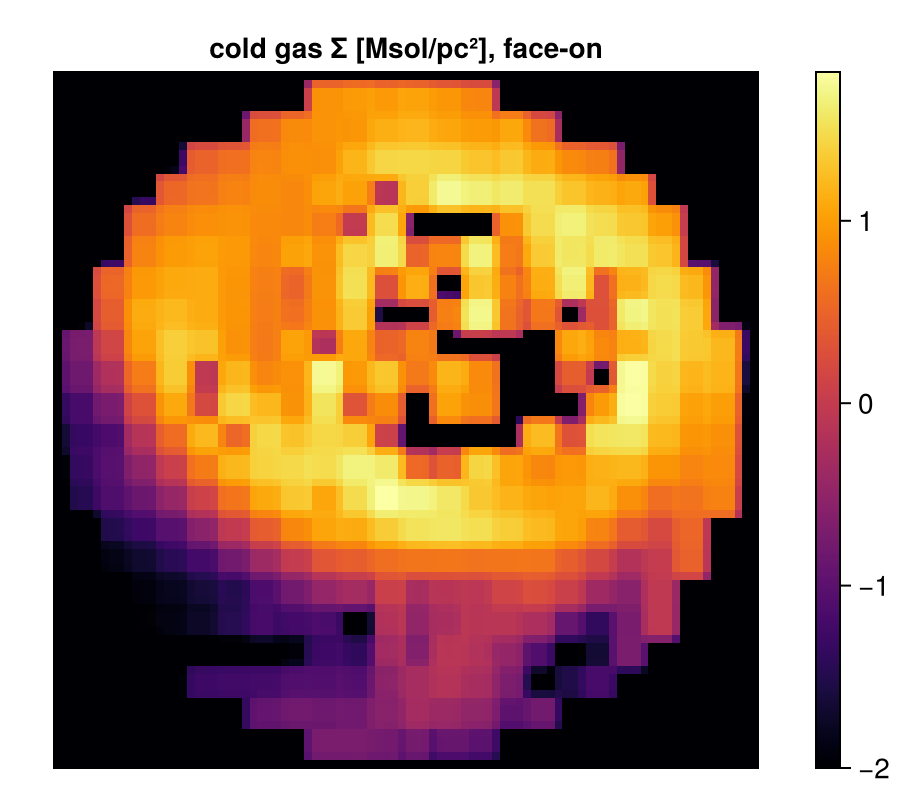

In [5]:
p = projection(cold, :sd, :Msol_pc2; direction=:faceon, center=[:bc],
               pxsize=[0.2, :kpc], verbose=false, show_progress=false)
fig = Figure(size=(460, 400))
ax = Axis(fig[1, 1], title="cold gas Σ [Msol/pc²], face-on", aspect=DataAspect())
hm = heatmap!(ax, log10.(max.(p.maps[:sd], 1e-2)), colormap=:inferno)
Colorbar(fig[1, 2], hm)
hidedecorations!(ax)
fig

In [6]:
out = mktempdir()                                   # any existing folder
savedata(cold, out; fmode=:write, verbose=false)    # writes output_00100.jld2 (JLD2)
back = loaddata(100, out, :hydro, verbose=false)    # instant reload — no raw-snapshot re-read
println("round-trip ok: ", length(back.data) == length(cold.data), "  (",
        round(filesize(joinpath(out, "output_00100.jld2")) / 1024^2, digits=1), " MB on disk)")

round-trip ok: true  (1.3 MB on disk)


## Differences to expect, honestly

- **First call is slower, loops are fast.** Julia compiles on first use (see
  [Julia for Simulation Analysis](julia_for_simulation_analysis.md)); after that, custom
  per-cell analysis loops run at compiled speed — no need to push work into vectorised
  library calls for performance.
- **Units are explicit, not attached.** Quantities are plain arrays; units enter as scale
  factors or unit symbols. This keeps everything zero-overhead but means *you* choose the unit
  at each call.
- **The multi-code promise:** the same verbs run on every code Mera reads (RAMSES, PLUTO,
  Chombo, Athena++, FLASH, GADGET/AREPO-family) — see
  [Other Simulation Codes](multicode.md) and `supports(info, :hydro)` for per-code capabilities.

**Next:** [Julia for Simulation Analysis](julia_for_simulation_analysis.md) — environments,
compile-time latency, memory habits and measured multithreading.
